Pressione [s] para salvar as imagens ou [q] para sair.


QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: C

odict_items([('mouth', (48, 68)), ('inner_mouth', (60, 68)), ('right_eyebrow', (17, 22)), ('left_eyebrow', (22, 27)), ('right_eye', (36, 42)), ('left_eye', (42, 48)), ('nose', (27, 36)), ('jaw', (0, 17))])


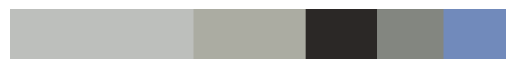

Cores dominantes (HEX):
#bdbfbc
#abaca2
#2b2826
#838680
#718abb


In [1]:
import import_ipynb

import cv2
import os
import numpy as np
import analise_tom
import deteccao_facial
import color_extract
from colormath.color_objects import LabColor, sRGBColor, HSVColor
from colormath.color_conversions import convert_color

def analysis(imgpath):
    #######################################
    #           Face detection            #
    #######################################
    df = deteccao_facial.DetectFace(imgpath)
    face = [df.left_cheek, df.right_cheek,
            df.left_eyebrow, df.right_eyebrow,
            df.left_eye, df.right_eye]

    #######################################
    #         Get Dominant Colors         #
    #######################################
    temp = []
    clusters = 4
    for f in face:
        dc = color_extract.DominantColors(f, clusters)
        face_part_color, _ = dc.getHistogram()
        #dc.plotHistogram()
        temp.append(np.array(face_part_color[0]))
    cheek = np.mean([temp[0], temp[1]], axis=0)
    eyebrow = np.mean([temp[2], temp[3]], axis=0)
    eye = np.mean([temp[4], temp[5]], axis=0)

    Lab_b, hsv_s = [], []
    color = [cheek, eyebrow, eye]
    for i in range(3):
        rgb = sRGBColor(color[i][0], color[i][1], color[i][2], is_upscaled=True)
        lab = convert_color(rgb, LabColor, through_rgb_type=sRGBColor)
        hsv = convert_color(rgb, HSVColor, through_rgb_type=sRGBColor)
        Lab_b.append(float(format(lab.lab_b,".2f")))
        hsv_s.append(float(format(hsv.hsv_s,".2f"))*100)

    print('Lab_b[skin, eyebrow, eye]',Lab_b)
    print('hsv_s[skin, eyebrow, eye]',hsv_s)
    #######################################
    #      Personal color Analysis        #
    #######################################
    Lab_weight = [30, 20, 5]
    hsv_weight = [10, 1, 1]
    if(analise_tom.is_warm(Lab_b, Lab_weight)):
        if(analise_tom.is_spr(hsv_s, hsv_weight)):
            tone = 'tom quente de primavera(spring)'
        else:
            tone = 'Tom quente de outono(fall)'
    else:
        if(analise_tom.is_smr(hsv_s, hsv_weight)):
            tone = 'tom fresco de verão(summer)'
        else:
            tone = 'Tom legal de inverno(winter)'
    # Print Result
    print('A coloração pessoal de {} é {}.'.format(os.path.basename(imgpath), tone))